Dataset shape: (100, 8, 32, 32, 3)
Q1


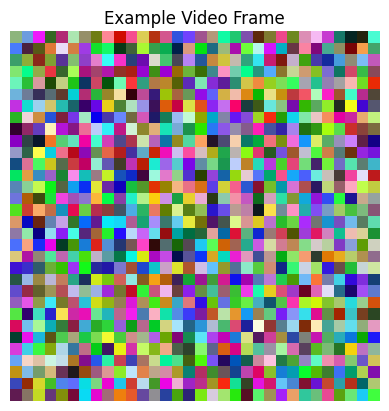

In [2]:
import numpy as np
import matplotlib.pyplot as plt

samples = 100
frames = 8
height = 32
width = 32
channels = 3

X = np.random.rand(samples, frames, height, width, channels)

print("Dataset shape:", X.shape)

# visualize one frame
frame = X[0,0]

plt.imshow(frame)
print("Q1")
plt.title("Example Video Frame")
plt.axis("off")
plt.show()

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense

model = Sequential()

model.add(Conv3D(32, (3,3,3), activation='relu',
                 input_shape=(8,32,32,3)))

# ✅ FIXED (no time reduction)
model.add(MaxPooling3D((1,2,2)))

model.add(Conv3D(64, (3,3,3), activation='relu'))

# ✅ FIXED again
model.add(MaxPooling3D((1,2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))
print("Q2")

model.summary()

Q2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_8 (Conv3D)               │ (None, 6, 30, 30, 32)  │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 6, 15, 15, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_9 (Conv3D)               │ (None, 4, 13, 13, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_9 (MaxPooling3D)  │ (None, 4, 6, 6, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,238,147 (4.72 MB)

 Trainable params: 1,238,147 (4.72 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
print("Q3")
# Generate labels
y = np.random.randint(0,3,100)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=8,
    validation_split=0.2
)

Q3
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - accuracy: 0.3750 - loss: 1.3335 - val_accuracy: 0.2500 - val_loss: 1.2348
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.3500 - loss: 1.1021 - val_accuracy: 0.3000 - val_loss: 1.1013
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.3750 - loss: 1.1031 - val_accuracy: 0.3000 - val_loss: 1.1225
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step - accuracy: 0.3500 - loss: 1.0895 - val_accuracy: 0.3500 - val_loss: 1.1364
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.4250 - loss: 1.0837 - val_accuracy: 0.3000 - val_loss: 1.1425


Q4


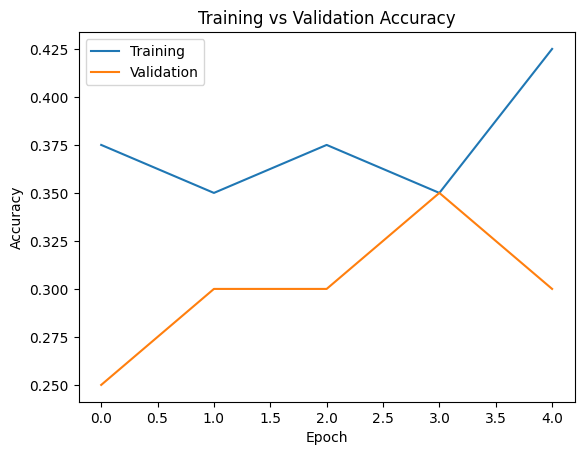

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
print("Q4")
plt.show()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv3D(32,(3,3,3),activation='relu',
                 input_shape=(8,32,32,3)))

# ✅ FIX: do NOT reduce time dimension
model.add(MaxPooling3D((1,2,2)))

model.add(Conv3D(64,(3,3,3),activation='relu'))

# ✅ FIX again
model.add(MaxPooling3D((1,2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))

# ✅ Dropout is correct
model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_14 (Conv3D)              │ (None, 6, 30, 30, 32)  │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_14 (MaxPooling3D) │ (None, 6, 15, 15, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_15 (Conv3D)              │ (None, 4, 13, 13, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_15 (MaxPooling3D) │ (None, 4, 6, 6, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,238,147 (4.72 MB)

 Trainable params: 1,238,147 (4.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 257ms/step - accuracy: 0.3625 - loss: 2.0080 - val_accuracy: 0.1000 - val_loss: 1.2076
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.4250 - loss: 1.0955 - val_accuracy: 0.1000 - val_loss: 1.1449
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.3375 - loss: 1.0936 - val_accuracy: 0.1000 - val_loss: 1.1156
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.4000 - loss: 1.0927 - val_accuracy: 0.1000 - val_loss: 1.1420
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - accuracy: 0.4125 - loss: 1.0860 - val_accuracy: 0.1000 - val_loss: 1.1827


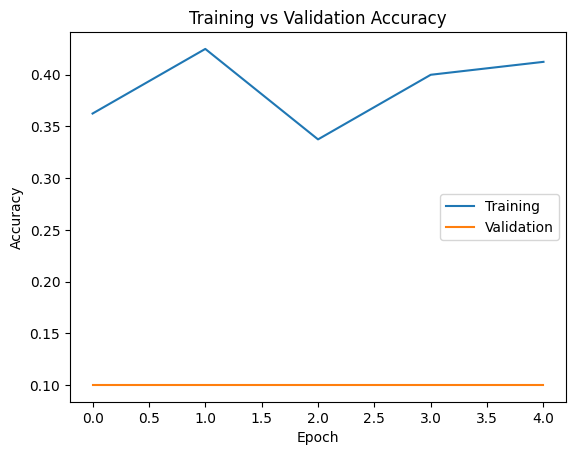

In [17]:
y = np.random.randint(0,3,100)
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
history = model.fit(
X,
y,
epochs=5,
batch_size=8,
validation_split=0.2
)
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.show()